# Bivariate analysis of categorical variables and the chi-square test

This notebook presents a bivariate analysis of categorical variables, specifically examining the relationship between individuals' countrys of origin, birth years and genders. A chi-square test is employed to determine if there is a statistically significant association between these factors over time. 

The aim is to understand how the geographical distribution of the population has changed over time and whether there is a significant over-representation of female astronomers/physicists in certain countrys.


In [19]:
import pandas as pd

import scipy.stats as stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import seaborn as sns

In [20]:
import pprint
import csv
import sys

import time
import datetime
from dateutil import parser
from shutil import copyfile


In [21]:
import warnings
warnings.filterwarnings('ignore')


## Create a dataframe with the data to be analysed

We use in this notebook the data produced in the da2 chapter, i.e. a list of persons with birth year, gender, place of birth, world country of birth

In [22]:
csv_address='da_data/da3-birthYear-gender-region-country.csv'
df_p = pd.read_csv(csv_address)
df_p.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1806,male,Prince William County,POINT (-77.48 38.7),http://www.wikidata.org/entity/Q183263,1801-1810,23,Northern America,US,United States,United States,USA
1,http://www.wikidata.org/entity/Q5400003,Adolphe Hugentobler,1810,male,Cortaillod,POINT (6.84793 46.94399),http://www.wikidata.org/entity/Q70308,1801-1810,22,Western Europe,CH,Schweiz-Suisse-Svizzera-Svizra,Switzerland,CHE
2,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,1801,male,Arleux,POINT (3.106389 50.280278),http://www.wikidata.org/entity/Q61573,1801-1810,22,Western Europe,FR,France,France,FRA
3,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,1806,male,La Rivière-Saint-Sauveur,POINT (0.271389 49.407222),http://www.wikidata.org/entity/Q383959,1801-1810,22,Western Europe,FR,France,France,FRA
4,http://www.wikidata.org/entity/Q234570,Harriet Martineau,1802,female,Norwich,POINT (1.292778 52.628611),http://www.wikidata.org/entity/Q130191,1801-1810,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR


In [23]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9479 entries, 0 to 9478
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   uriPer      9479 non-null   object
 1   labelPer    9479 non-null   object
 2   birthYear   9479 non-null   int64 
 3   gender      9479 non-null   object
 4   labelPlace  9479 non-null   object
 5   geometry    9479 non-null   object
 6   uriPlace    9479 non-null   object
 7   periods     9479 non-null   object
 8   FID         9479 non-null   int64 
 9   REGION      9479 non-null   object
 10  CNTR_ID     9479 non-null   object
 11  CNTR_NAME   9479 non-null   object
 12  NAME_ENGL   9479 non-null   object
 13  ISO3_CODE   9479 non-null   object
dtypes: int64(2), object(12)
memory usage: 1.0+ MB


### Verify variables: gender

In [24]:
### Group and count
# We observe some dispersion that requires grouping the categories of the variable
df_gender = df_p.groupby('gender').size()
df_gender = pd.DataFrame(df_gender.sort_values(ascending = False))
df_gender.columns=['number']
print(df_gender)

        number
gender        
male      7269
female    2210


## Distribution of countries of birth

In [25]:
### Group and count
# We observe some dispersion that requires grouping the categories of the variable
df_country = df_p.groupby('NAME_ENGL').size()
df_country = pd.DataFrame(df_country.sort_values(ascending = False))
df_country.columns=['number']
print(df_country.iloc[:50])
#print(df_country[(df_country.number < 21) & (df_country.number >5)])



                    number
NAME_ENGL                 
Germany               1604
United States          879
France                 579
Italy                  559
Poland                 511
Czechia                484
Japan                  361
Spain                  356
Russian Federation     331
Hungary                278
United Kingdom         249
Brazil                 224
Austria                211
Slovenia               153
Netherlands            139
Romania                136
Ukraine                132
Switzerland            124
Canada                 115
Argentina              115
Belgium                 83
Peru                    79
Iran                    73
Norway                  73
Chile                   73
Finland                 67
Israel                  67
Mexico                  63
Belarus                 63
China                   62
India                   58
Türkiye                 53
Slovakia                48
Estonia                 45
Serbia                  45
D

In [26]:
### Example of values
print(len(df_p[df_p.NAME_ENGL=='Chile']))
df_p[df_p.NAME_ENGL=='Chile'].head(3)

73


,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE
55,http://www.wikidata.org/entity/Q10288670,Jenaro Abásolo,1833,male,Santiago,POINT (-70.65 -33.4375),http://www.wikidata.org/entity/Q2887,1831-1840,15,South America,CL,Chile,Chile,CHL
890,http://www.wikidata.org/entity/Q315094,Carlos Keller,1898,male,Concepción,POINT (-73.050278 -36.826944),http://www.wikidata.org/entity/Q1880,1891-1900,15,South America,CL,Chile,Chile,CHL
959,http://www.wikidata.org/entity/Q106369203,Oscar Alvarez Andrews,1897,male,Santiago,POINT (-70.65 -33.4375),http://www.wikidata.org/entity/Q2887,1891-1900,15,South America,CL,Chile,Chile,CHL


In [27]:
### We define a function that codes and aggregates the values in order to avoid dispersion, 
# which would make them difficult to analyse.

def codeCountry(country: str):
    if 'Russian Federation' in country \
        or 'Kazakhstan' in country \
        or 'Georgia' in country \
        or 'Uzbekistan' in country \
        or 'Armenia' in country \
        or 'Azerbaijan' in country:
        output='Russian Federation'
    elif 'Estonia' in country \
        or 'Latvia' in country \
        or 'Finland' in country \
        or 'Belarus' in country \
        or 'Lithuania' in country:
        output='Baltic States Fin. Belar.'
    elif 'Moldova' in country \
        or 'Serbia' in country \
        or 'Slovenia' in country \
        or 'Slovakia' in country \
        or 'Romania' in country \
        or 'Croatia' in country \
        or 'Bulgaria' in country:
        output='Central Europe'
    elif 'Norway' in country \
        or 'Denmark' in country \
        or 'Sweden' in country:
        output='Scandinavia'
    elif 'Argentina' in country \
        or 'Brazil' in country \
        or 'Chile' in country:
        output='South America'    
    elif 'Spain' in country \
        or 'Portugal' in country:
        output='Spain Port.'    
    elif 'Belgium' in country \
        or 'Netherlands' in country:
        output='Belgium Netherl.'   
    elif 'Australia' in country \
        or 'New Zealand' in country:
        output='Australia New Z.'      
    elif 'Canada' in country \
        or 'United States' in country:
        output='United States Can.'   
    elif 'Austria' in country \
        or 'Hungary' in country:
        output='Austria Hungary'       
    else:
        output=country
    return output                   

In [28]:
### Test the function
r='Belgium'
#r='Latvia'
codeCountry(r)

'Belgium Netherl.'

In [29]:
### Create a new column with the coded values
df_p['coded_country']=df_p.NAME_ENGL.apply(lambda x : codeCountry(x))

In [30]:
### Example
df_p.iloc[31:35]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country
31,http://www.wikidata.org/entity/Q1803058,Roberto Ardigò,1828,male,Casteldidone,POINT (10.4 45.066667),http://www.wikidata.org/entity/Q42837,1821-1830,19,Southern Europe,IT,Italia,Italy,ITA,Italy
32,http://www.wikidata.org/entity/Q191026,Francis Galton,1822,male,Sparkbrook,POINT (-1.8712 52.462),http://www.wikidata.org/entity/Q2593284,1821-1830,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom
33,http://www.wikidata.org/entity/Q120664,Nikolay Danilevsky,1822,male,Livenskiy Uyezd,POINT (37.6 52.416667),http://www.wikidata.org/entity/Q4260978,1821-1830,9,European Russia,RU,Россия,Russian Federation,RUS,Russian Federation
34,http://www.wikidata.org/entity/Q401209,Ahmet Cevdet Pasha,1822,male,Lovech,POINT (24.711535 43.134777),http://www.wikidata.org/entity/Q189328,1821-1830,8,Eastern Europe,BG,България,Bulgaria,BGR,Central Europe


In [31]:
### Group and count
df_country = df_p.groupby('coded_country').size()
df_country = pd.DataFrame(df_country.sort_values(ascending = False))
#df_contCode.reset_index(inplace=True)
df_country.columns=['number']
df_country.iloc[:50]

,number
coded_country,
Germany,1604
United States Can.,994
France,579
Italy,559
Poland,511
Austria Hungary,489
Czechia,484
Central Europe,466
South America,412


In [34]:
### countries with more than 100 persons (Israel and Australia are excluded)
df_country_200 = df_country[df_country.number > 200]
print(len(df_country_200))

15


In [35]:
df_country_200

,number
coded_country,
Germany,1604
United States Can.,994
France,579
Italy,559
Poland,511
Austria Hungary,489
Czechia,484
Central Europe,466
South America,412


In [36]:
lc200=df_country_200.index.to_list()
lc200

['Germany',
 'United States Can.',
 'France',
 'Italy',
 'Poland',
 'Austria Hungary',
 'Czechia',
 'Central Europe',
 'South America',
 'Spain Port.',
 'Russian Federation',
 'Japan',
 'United Kingdom',
 'Belgium Netherl.',
 'Baltic States Fin. Belar.']

### Limit the analysis to persons with a coded birth country

In [37]:
df_pa = df_p[df_p.coded_country.isin(lc200)]

In [38]:
print('df_p:', len(df_p), '/ dfpa:', len(df_pa))
df_pa.iloc[31:35]

df_p: 9479 / dfpa: 7917


,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country
34,http://www.wikidata.org/entity/Q401209,Ahmet Cevdet Pasha,1822,male,Lovech,POINT (24.711535 43.134777),http://www.wikidata.org/entity/Q189328,1821-1830,8,Eastern Europe,BG,България,Bulgaria,BGR,Central Europe
35,http://www.wikidata.org/entity/Q3968193,Stanislao Solari,1829,male,Genoa,POINT (8.933983 44.407186),http://www.wikidata.org/entity/Q1449,1821-1830,19,Southern Europe,IT,Italia,Italy,ITA,Italy
36,http://www.wikidata.org/entity/Q337628,Pyotr Lavrov,1823,male,Melekhovo,POINT (29.46278 56.87861),http://www.wikidata.org/entity/Q18790174,1821-1830,9,European Russia,RU,Россия,Russian Federation,RUS,Russian Federation
37,http://www.wikidata.org/entity/Q61897268,Charles Robert,1827,male,Mulhouse,POINT (7.339167 47.748611),http://www.wikidata.org/entity/Q79815,1821-1830,22,Western Europe,FR,France,France,FRA,France


### Transform birth years to periods of activity years

In [41]:
### Create imputed activity year
df_pa['activityYear'] = df_pa.birthYear.apply(lambda x : int(x)+45)

In [44]:
print(df_pa.columns)

Index(['uriPer', 'labelPer', 'birthYear', 'gender', 'labelPlace', 'geometry',
       'uriPlace', 'periods', 'FID', 'REGION', 'CNTR_ID', 'CNTR_NAME',
       'NAME_ENGL', 'ISO3_CODE', 'coded_country', 'activityYear'],
      dtype='object')


In [45]:
df_pa = df_pa.drop([ 'periods'], axis=1)

In [46]:
### Create list of 25 years periods

yr = df_pa.activityYear

l_25 = list(range(min(yr), max(yr), 25))
print(l_25[:5],l_25[-5:], len(l_25)-1)

[1846, 1871, 1896, 1921, 1946] [1921, 1946, 1971, 1996, 2021] 7


In [47]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# A new column is added containing the period, based on the previous list and the year value

df_pa['periodsActivity'] = pd.cut(df_pa['activityYear'], l_25, right=False)

### Rewrite the added code to make it more readable
df_pa['periodsActivity'] = df_pa['periodsActivity'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

In [50]:
# Inspection
df_pa.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1806,male,Prince William County,POINT (-77.48 38.7),http://www.wikidata.org/entity/Q183263,23,Northern America,US,United States,United States,USA,United States Can.,1851,1846-1870
2,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,1801,male,Arleux,POINT (3.106389 50.280278),http://www.wikidata.org/entity/Q61573,22,Western Europe,FR,France,France,FRA,France,1846,1846-1870
3,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,1806,male,La Rivière-Saint-Sauveur,POINT (0.271389 49.407222),http://www.wikidata.org/entity/Q383959,22,Western Europe,FR,France,France,FRA,France,1851,1846-1870


In [51]:
### Distribution of activities by 25 years periods
activities_per = pd.DataFrame(df_pa.groupby(by='periodsActivity').size())
activities_per.columns=['number']
print(activities_per)

                 number
periodsActivity        
1846-1870            36
1871-1895           100
1896-1920           278
1921-1945           460
1946-1970          1005
1971-1995          3202
1996-2020          2437


#### Prepare the data for the AFC, cf. challenge da4

In [52]:
file_address='da_data/da4-AFC.csv'
df_pa.to_csv(file_address, index=False)

## Bivariate analysis coded countries and activity periods

* A contingency table organises data to show the frequency of two or more categorical variables arranged in rows and columns, revealing possible relationships between them.
* Frequency counts are produced by calculating how often each combination of categories occurs in the dataset.

In [73]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_country=pd.crosstab(df_pa.periodsActivity, df_pa.coded_country, margins=True)

## display all columns
pd.set_option('display.max_columns', None)

per_vs_country.iloc[2:]

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Japan,Poland,Russian Federation,South America,Spain Port.,United Kingdom,United States Can.,All
periodsActivity,,,,,,,,,,,,,,,,
1896-1920,13,4,7,27,12,39,29,18,4,15,5,12,16,15,62,278
1921-1945,39,14,10,34,36,30,94,16,13,33,20,11,11,8,91,460
1946-1970,63,34,42,51,83,86,142,31,28,81,34,34,19,36,241,1005
1971-1995,184,85,99,149,175,234,646,212,154,200,164,207,138,126,429,3202
1996-2020,168,68,54,173,118,139,580,239,148,134,121,131,160,49,155,2437
All,470,207,217,440,425,562,1507,528,348,470,361,399,352,246,986,7518


In [74]:
observed = per_vs_country.iloc[2:-1, :-1 ]
observed

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Japan,Poland,Russian Federation,South America,Spain Port.,United Kingdom,United States Can.
periodsActivity,,,,,,,,,,,,,,,
1896-1920,13,4,7,27,12,39,29,18,4,15,5,12,16,15,62
1921-1945,39,14,10,34,36,30,94,16,13,33,20,11,11,8,91
1946-1970,63,34,42,51,83,86,142,31,28,81,34,34,19,36,241
1971-1995,184,85,99,149,175,234,646,212,154,200,164,207,138,126,429
1996-2020,168,68,54,173,118,139,580,239,148,134,121,131,160,49,155


In [75]:
### Calculation of parameters for the chi-square test
statistic, p, dof, expected = stats.chi2_contingency(observed)


In [76]:
dfe=pd.DataFrame(expected.round(0))
dfe.columns=observed.columns
dfe.index=observed.index
dfe

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Japan,Poland,Russian Federation,South America,Spain Port.,United Kingdom,United States Can.
periodsActivity,,,,,,,,,,,,,,,
1896-1920,18.0,8.0,8.0,16.0,16.0,20.0,56.0,19.0,13.0,17.0,13.0,15.0,13.0,9.0,37.0
1921-1945,29.0,13.0,13.0,27.0,26.0,33.0,93.0,32.0,22.0,29.0,21.0,25.0,21.0,15.0,61.0
1946-1970,64.0,28.0,29.0,59.0,58.0,72.0,203.0,70.0,47.0,63.0,47.0,54.0,47.0,32.0,133.0
1971-1995,203.0,89.0,92.0,188.0,184.0,229.0,647.0,224.0,151.0,201.0,149.0,171.0,149.0,101.0,424.0
1996-2020,154.0,68.0,70.0,143.0,140.0,174.0,492.0,170.0,115.0,153.0,114.0,130.0,114.0,77.0,323.0


In [77]:
## Degrees of freedom and Chi-square

print('Degrees of freedom:', dof, '; Chi-square value:', statistic.round(2))


Degrees of freedom: 56 ; Chi-square value: 541.85


In [78]:
### P-value
print('p-value :', p)

p-value : 1.0819174360627151e-80


In [79]:
### Cramér's V (normalized phi) coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(observed, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.1354635164508071


In [80]:
### Get signed resitduals using statmodels (sm)

# 1. Create the Table object directly from your data
table = sm.stats.Table(observed)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
adjusted_resids.round(1)

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Japan,Poland,Russian Federation,South America,Spain Port.,United Kingdom,United States Can.
periodsActivity,,,,,,,,,,,,,,,
1896-1920,-1.2,-1.4,-0.4,2.8,-1.0,4.5,-4.1,-0.3,-2.6,-0.6,-2.3,-0.8,0.9,2.2,4.5
1921-1945,2.0,0.4,-0.9,1.4,2.0,-0.5,0.1,-3.1,-2.0,0.8,-0.3,-2.9,-2.4,-1.8,4.3
1946-1970,-0.1,1.3,2.7,-1.2,3.7,1.9,-5.2,-5.2,-3.1,2.5,-2.1,-3.0,-4.5,0.8,10.8
1971-1995,-1.8,-0.6,1.0,-3.9,-0.9,0.5,-0.0,-1.1,0.4,-0.1,1.6,3.7,-1.2,3.3,0.3
1996-2020,1.4,0.0,-2.4,3.1,-2.3,-3.4,5.4,6.7,3.9,-1.9,0.9,0.1,5.5,-4.0,-12.3


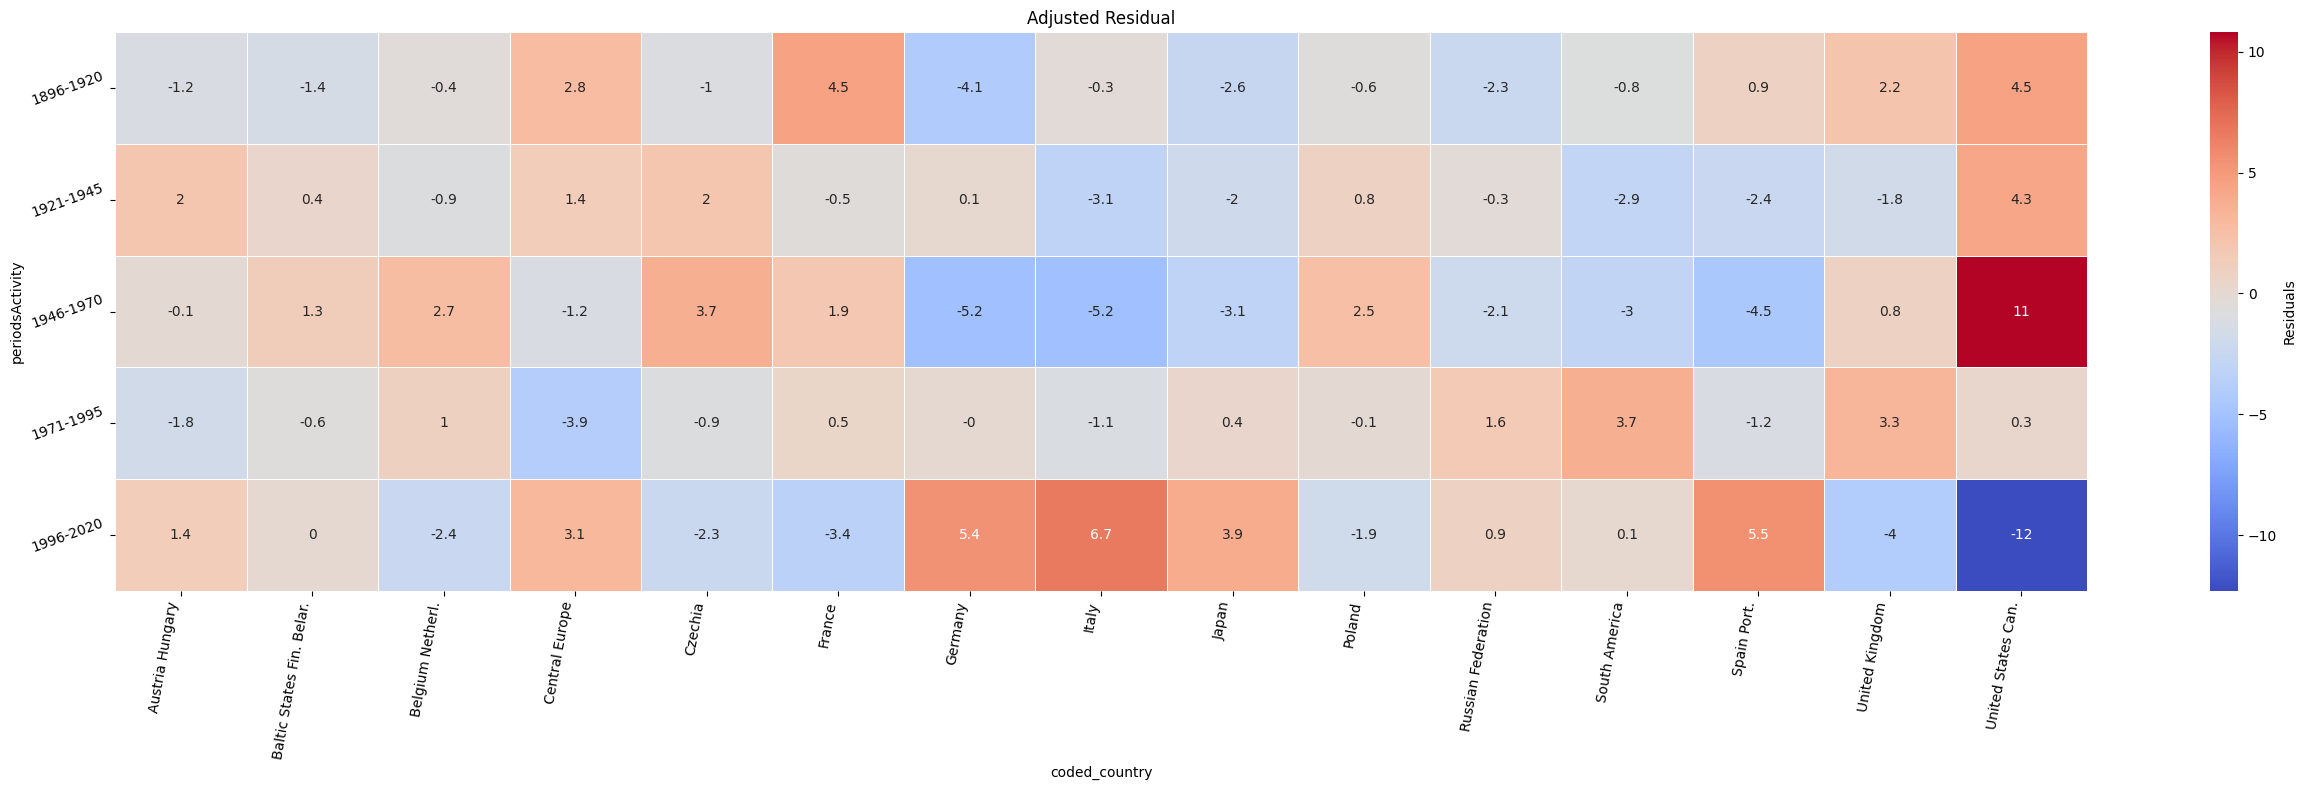

In [81]:
### Plot the residuals

# 3. Plot
fig, ax = plt.subplots(1,1,figsize=(26,8))         


# Create heatmap
sns.heatmap(
    adjusted_resids.round(1), 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')
ax.set_title("Adjusted Residual", fontsize=12)

# ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.tight_layout()
plt.show()

In [82]:
## Compare with number
per_vs_country.iloc[2:]

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Japan,Poland,Russian Federation,South America,Spain Port.,United Kingdom,United States Can.,All
periodsActivity,,,,,,,,,,,,,,,,
1896-1920,13,4,7,27,12,39,29,18,4,15,5,12,16,15,62,278
1921-1945,39,14,10,34,36,30,94,16,13,33,20,11,11,8,91,460
1946-1970,63,34,42,51,83,86,142,31,28,81,34,34,19,36,241,1005
1971-1995,184,85,99,149,175,234,646,212,154,200,164,207,138,126,429,3202
1996-2020,168,68,54,173,118,139,580,239,148,134,121,131,160,49,155,2437
All,470,207,217,440,425,562,1507,528,348,470,361,399,352,246,986,7518


## Bivariate analysis genders

In [83]:
gender_vs_country=pd.crosstab(df_pa.gender, df_pa.coded_country, margins=True)
gender_vs_country

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Japan,Poland,Russian Federation,South America,Spain Port.,United Kingdom,United States Can.,All
gender,,,,,,,,,,,,,,,,
female,108,63,41,118,131,111,351,127,44,112,74,151,94,55,214,1794
male,381,156,181,348,353,468,1253,432,317,399,301,261,299,194,780,6123
All,489,219,222,466,484,579,1604,559,361,511,375,412,393,249,994,7917


In [84]:
### Take the margins away
observed = gender_vs_country.iloc[:-1, :-1 ]
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(observed)
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 90.52236393417469 , dof : 14
p-value : 3.023480064107586e-13


In [85]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(observed, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.10692952088668636


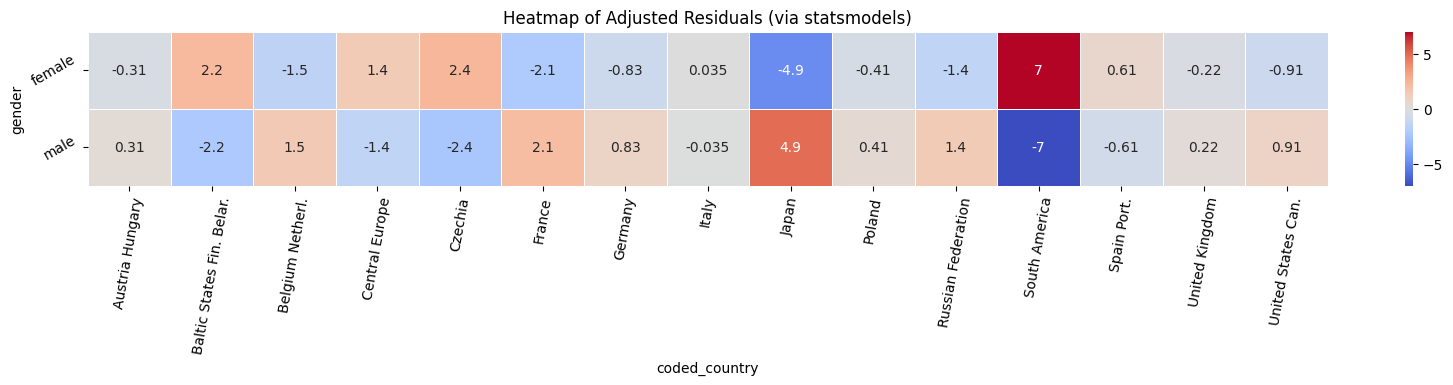

In [86]:
# 1. Create the Table object directly from your data
table = sm.stats.Table(observed)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(20,2))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()


We can observe that women are more present in some countries. The difference is statistically relevant although weak: Cramer's V = 0.116

## Bivariate analysis genders+generations vs countrys

In [87]:
def code_gender_period(gender: str):
    if gender == 'female':
        output='f'
    else:
        output='m'
    return output    

In [101]:
code_gender_period

<function __main__.code_gender_period(gender: str)>

In [106]:
df_pa['per_gender'] = df_pa.apply(
    lambda x: str(x.periodsActivity) + '_' + str(code_gender_period(x.gender)),
    axis=1
)
df_pa.head(2)


,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,per_gender
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1806,male,Prince William County,POINT (-77.48 38.7),http://www.wikidata.org/entity/Q183263,23,Northern America,US,United States,United States,USA,United States Can.,1851,1846-1870,1846-1870_m
2,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,1801,male,Arleux,POINT (3.106389 50.280278),http://www.wikidata.org/entity/Q61573,22,Western Europe,FR,France,France,FRA,France,1846,1846-1870,1846-1870_m


In [112]:
per_gender_vs_country=pd.crosstab(df_pa.per_gender, df_pa.coded_country, margins=True)
per_gender_vs_country.iloc[6:]

df_pa_no_nan = df_pa.dropna(subset=['periodsActivity'])

per_gender_vs_country = pd.crosstab(
    df_pa_no_nan['per_gender'],
    df_pa_no_nan['coded_country'],
    margins=True
)

per_gender_vs_country

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Japan,Poland,Russian Federation,South America,Spain Port.,United Kingdom,United States Can.,All
per_gender,,,,,,,,,,,,,,,,
1846-1870_f,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,3
1846-1870_m,0,0,2,2,0,12,3,1,0,1,5,0,0,5,2,33
1871-1895_f,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
1871-1895_m,3,2,3,4,1,22,12,10,1,6,11,4,8,6,6,99
1896-1920_f,0,0,0,1,0,1,3,0,0,1,1,0,0,4,13,24
1896-1920_m,13,4,7,26,12,38,26,18,4,14,4,12,16,11,49,254
1921-1945_f,6,1,1,1,1,1,13,1,0,3,0,2,2,1,17,50
1921-1945_m,33,13,9,33,35,29,81,15,13,30,20,9,9,7,74,410
1946-1970_f,12,2,7,3,7,11,20,2,1,21,6,7,0,6,39,144


In [114]:
### Only mor recent periods
observed = per_gender_vs_country.iloc[6:-1, :-1 ]
observed = observed[~observed.index.str.startswith('nan')]

In [115]:
### For significant chi-2 test minimal number in each cell of expected:5
# bias in the results
statistic, p, dof, expected = stats.chi2_contingency(observed)
dfe = pd.DataFrame(expected).round(0)
dfe.index = observed.index
dfe.columns = observed.columns
dfe

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Japan,Poland,Russian Federation,South America,Spain Port.,United Kingdom,United States Can.
per_gender,,,,,,,,,,,,,,,
1921-1945_f,3.0,1.0,1.0,3.0,3.0,3.0,10.0,4.0,2.0,3.0,2.0,3.0,2.0,2.0,6.0
1921-1945_m,26.0,12.0,12.0,23.0,24.0,28.0,84.0,29.0,20.0,26.0,20.0,22.0,19.0,13.0,53.0
1946-1970_f,9.0,4.0,4.0,8.0,8.0,10.0,30.0,10.0,7.0,9.0,7.0,8.0,7.0,4.0,19.0
1946-1970_m,55.0,24.0,25.0,49.0,50.0,59.0,177.0,60.0,42.0,54.0,41.0,46.0,40.0,27.0,111.0
1971-1995_f,40.0,18.0,18.0,36.0,37.0,43.0,130.0,44.0,30.0,40.0,30.0,34.0,29.0,19.0,81.0
1971-1995_m,164.0,73.0,74.0,147.0,149.0,177.0,529.0,180.0,124.0,162.0,123.0,139.0,119.0,79.0,332.0
1996-2020_f,48.0,21.0,21.0,43.0,43.0,51.0,153.0,52.0,36.0,47.0,36.0,40.0,34.0,23.0,96.0
1996-2020_m,108.0,48.0,49.0,97.0,98.0,116.0,348.0,119.0,82.0,107.0,81.0,91.0,78.0,52.0,218.0


In [116]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 654.3929100341475 , dof : 98
p-value : 3.8540927630569706e-83


In [117]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(observed, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.11471462672503241


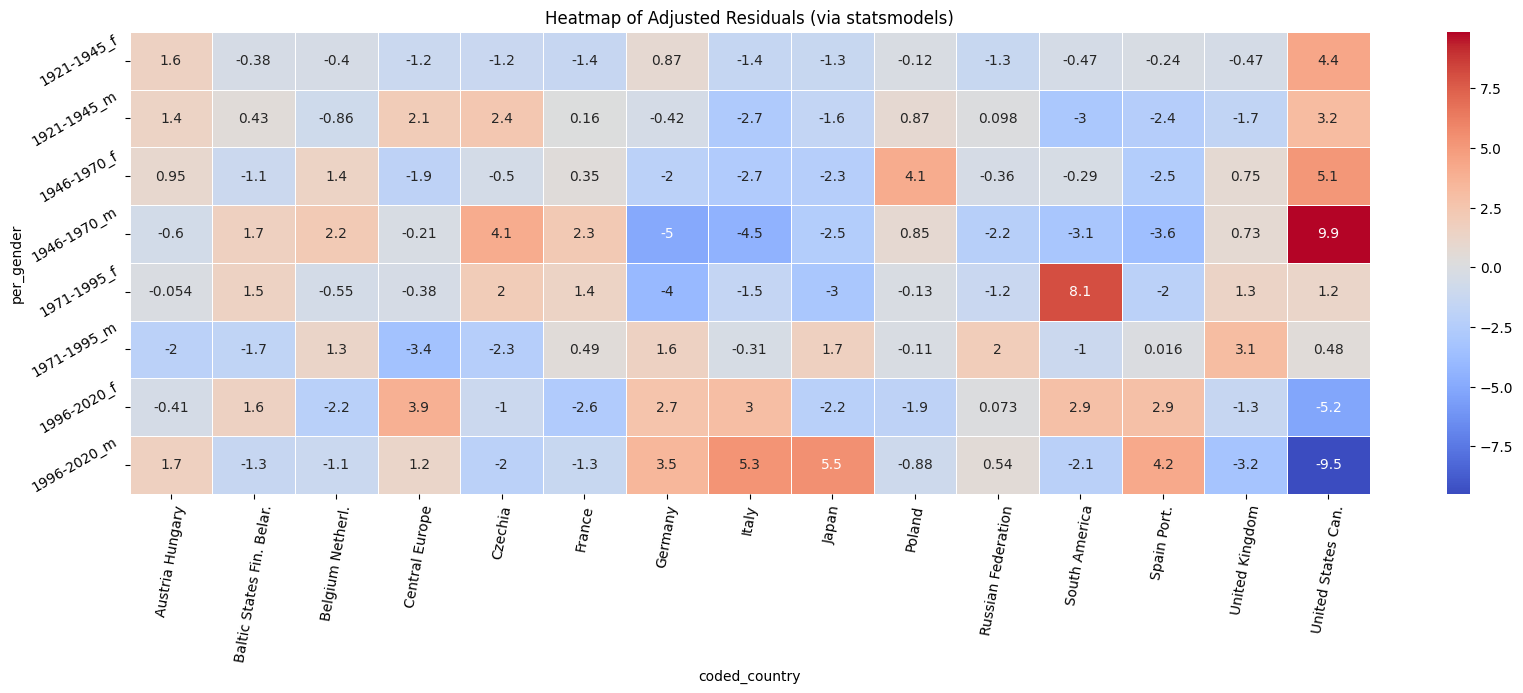

In [118]:
# 1. Create the Table object directly from your data
table = sm.stats.Table(observed)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(20,6))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()


In [121]:
dfs = df_pa[(df_pa.per_gender.isin(['1996-2020_f']))&(df_pa.coded_country.isin(['South America', 'Spain Port.']))]
print(len(dfs))

107


In [122]:
dfs.head(10)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,per_gender
6067,http://www.wikidata.org/entity/Q8772477,Edurne Uriarte,1960,female,Fruiz,POINT (-2.789501 43.327652),http://www.wikidata.org/entity/Q648519,19,Southern Europe,ES,España,Spain,ESP,Spain Port.,2005,1996-2020,1996-2020_f
6074,http://www.wikidata.org/entity/Q20871630,Helena Béjar,1956,female,Madrid,POINT (-3.703333 40.416944),http://www.wikidata.org/entity/Q2807,19,Southern Europe,ES,España,Spain,ESP,Spain Port.,2001,1996-2020,1996-2020_f
6109,http://www.wikidata.org/entity/Q55999172,Claudia Hilb,1955,female,Buenos Aires,POINT (-58.381944 -34.599722),http://www.wikidata.org/entity/Q1486,15,South America,AR,Argentina,Argentina,ARG,South America,2000,1996-2020,1996-2020_f
6198,http://www.wikidata.org/entity/Q18714132,Rosa Cobo Bedía,1956,female,Cantabria,POINT (-4 43.333333),http://www.wikidata.org/entity/Q3946,19,Southern Europe,ES,España,Spain,ESP,Spain Port.,2001,1996-2020,1996-2020_f
6225,http://www.wikidata.org/entity/Q8963180,Fátima Pelaes,1959,female,Macapá,POINT (-51.065311 0.032958),http://www.wikidata.org/entity/Q180215,15,South America,BR,Brasil,Brazil,BRA,South America,2004,1996-2020,1996-2020_f
6251,http://www.wikidata.org/entity/Q136528029,Pilar Maldonado Moya,1957,female,Alcañiz,POINT (-0.132957 41.050254),http://www.wikidata.org/entity/Q572800,19,Southern Europe,ES,España,Spain,ESP,Spain Port.,2002,1996-2020,1996-2020_f
6255,http://www.wikidata.org/entity/Q24089165,Capitolina Díaz,1952,female,Villadepalos,POINT (-6.752778 42.5375),http://www.wikidata.org/entity/Q6162578,19,Southern Europe,ES,España,Spain,ESP,Spain Port.,1997,1996-2020,1996-2020_f
6312,http://www.wikidata.org/entity/Q21856292,Paula Marcela Urroz,1955,female,Buenos Aires,POINT (-58.381944 -34.599722),http://www.wikidata.org/entity/Q1486,15,South America,AR,Argentina,Argentina,ARG,South America,2000,1996-2020,1996-2020_f
6330,http://www.wikidata.org/entity/Q113076836,María Lía Zervino,1951,female,Buenos Aires,POINT (-58.381944 -34.599722),http://www.wikidata.org/entity/Q1486,15,South America,AR,Argentina,Argentina,ARG,South America,1996,1996-2020,1996-2020_f
6430,http://www.wikidata.org/entity/Q61642655,Cecilia Loreto Mariz,1956,female,Recife,POINT (-34.880833 -8.053889),http://www.wikidata.org/entity/Q48344,15,South America,BR,Brasil,Brazil,BRA,South America,2001,1996-2020,1996-2020_f


### Inspected persons

* [Josefa Masegosa Gallego](http://www.wikidata.org/entity/Q19812690) (Spain)
* [Judith Desimoni](http://www.wikidata.org/entity/Q62072509) (Argentina)